In [1]:
import yfinance as yf
import pandas as pd

In [4]:
def get_stock_data(ticker,start_date,end_date):
    data = yf.download(ticker,start=start_date,end=end_date)
    data.columns = data.columns.get_level_values(0)
    return data

In [ ]:
tickers= ['AAPL','MSFT','600519.SS','000001.SZ']


In [8]:
all_data={}
for ticker in tickers:
    all_data[ticker] = get_stock_data(ticker,'2025-01-01','2026-01-01')

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/yfinance/scrapers/history.py:472: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  self._capital_gains = pd.Series()
[*********************100%***********************]  1 of 1 completed
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/yfinance/scrapers/history.py:472: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  self._capital_gains = pd.Series()
[*********************100%***********************]  1 of 1 completed
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/yfinance/scrapers/history.py:472: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype e

In [10]:
maotai_data=all_data['600519.SS']
maotai_data['return']=maotai_data['Close'].pct_change()

In [14]:
volatility = maotai_data['return'].std()
print(volatility)
annual_volatility = volatility * (252 ** 0.5)
print(annual_volatility)

0.010636030452867417
0.16884174909118127


In [16]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

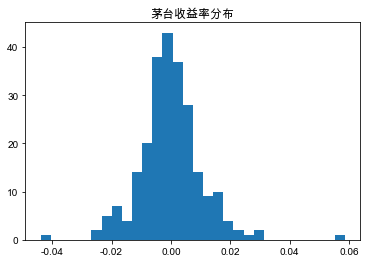

In [18]:
fig , ax = plt.subplots()
ax.hist(maotai_data['return'].dropna(),bins=30)
ax.set_title('茅台收益率分布')
fig.savefig('茅台收益率分布.png',dpi=300)
plt.show()

In [19]:
maotai_data['MA5'] = maotai_data['Close'].rolling(window=5).mean()
maotai_data['MA20'] = maotai_data['Close'].rolling(window=20).mean()

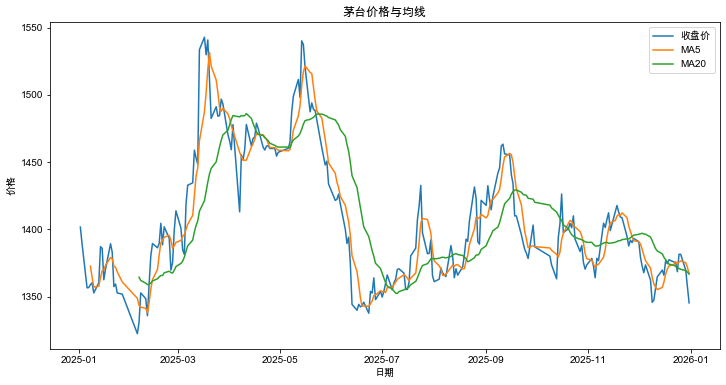

In [22]:
fig, ax = plt.subplots()
ax.plot(maotai_data.index,maotai_data['Close'],label='收盘价')
ax.plot(maotai_data.index,maotai_data['MA5'],label='MA5')
ax.plot(maotai_data.index,maotai_data['MA20'],label='MA20')
ax.legend()
ax.set_title('茅台价格与均线')
ax.set_xlabel('日期')
ax.set_ylabel('价格')
fig.set_size_inches(12, 6)
fig.savefig('茅台价格与均线.png', dpi=300)
plt.show()

In [24]:
returns_dict = {}
for ticker, data in all_data.items():
    returns_dict[ticker] = data['Close'].pct_change()
returns_df = pd.DataFrame(returns_dict)    

In [26]:
correlation_matrix = returns_df.corr()
correlation_matrix

,AAPL,MSFT,600519.SS,000001.SZ
AAPL,1.000000,0.486207,-0.035948,0.004137
MSFT,0.486207,1.000000,-0.032777,-0.012869
600519.SS,-0.035948,-0.032777,1.000000,0.316843
000001.SZ,0.004137,-0.012869,0.316843,1.000000


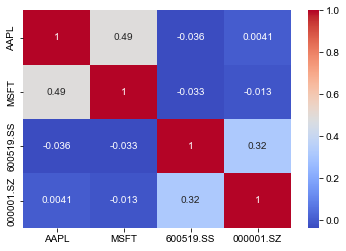

In [27]:
import seaborn as sns
fig, ax = plt.subplots()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', ax=ax)
fig.savefig('股票相关性热力图.png',dpi=300)
plt.show()